In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Prediction based on values close by (we did this before)

In [2]:
family_heights = Table.read_table('data/family_heights.csv')
family_heights

family,father,mother,midparentHeight,children,childNum,sex,childHeight
1,78.5,67,75.43,4,1,male,73.2
1,78.5,67,75.43,4,2,female,69.2
1,78.5,67,75.43,4,3,female,69
1,78.5,67,75.43,4,4,female,69
2,75.5,66.5,73.66,4,1,male,73.5
2,75.5,66.5,73.66,4,2,male,72.5
2,75.5,66.5,73.66,4,3,female,65.5
2,75.5,66.5,73.66,4,4,female,65.5
3,75,64,72.06,2,1,male,71
3,75,64,72.06,2,2,female,68


In [5]:
heights = family_heights.relabeled(['midparentHeight', 'childHeight'], ['MidParent', 'Child']).select('MidParent', 'Child')
heights

MidParent,Child
75.43,73.2
75.43,69.2
75.43,69
75.43,69
73.66,73.5
73.66,72.5
73.66,65.5
73.66,65.5
72.06,71
72.06,68


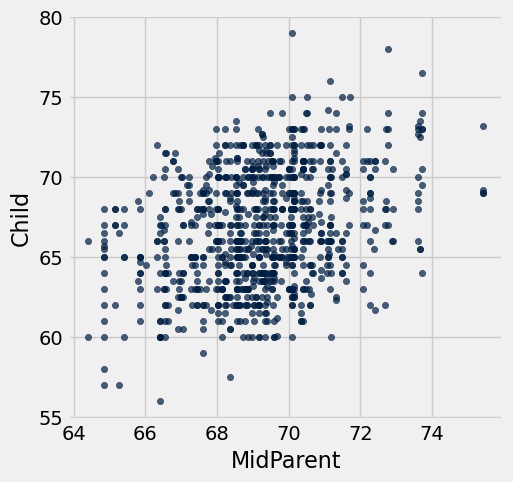

In [6]:
heights.scatter('MidParent')

In [7]:
def predict_child(mp_height):
    close_points = heights.where('MidParent', are.between(mp_height - 0.5, mp_height + 0.5))
    return close_points.column('Child').mean()

In [8]:
predict_child(71)

67.740594059405936

In [9]:
heights

MidParent,Child
75.43,73.2
75.43,69.2
75.43,69
75.43,69
73.66,73.5
73.66,72.5
73.66,65.5
73.66,65.5
72.06,71
72.06,68


In [12]:
heights_with_predictions = heights.with_column(
    'Prediction', heights.apply(predict_child, 'MidParent')
)
heights_with_predictions

MidParent,Child,Prediction
75.43,73.2,70.1
75.43,69.2,70.1
75.43,69,70.1
75.43,69,70.1
73.66,73.5,70.4158
73.66,72.5,70.4158
73.66,65.5,70.4158
73.66,65.5,70.4158
72.06,71,68.5025
72.06,68,68.5025


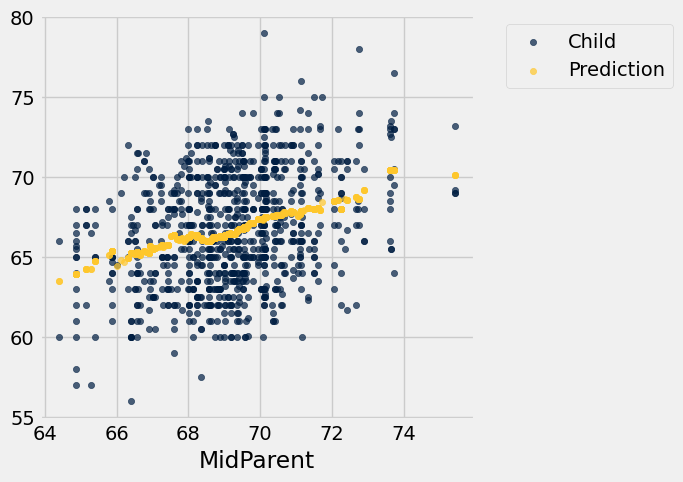

In [13]:
heights_with_predictions.scatter('MidParent')

# Correlation

In [15]:
# don't worry about this code
def r_scatter(r):
    'Generate a scatter plot with a correlation approximately r'
    plt.figure(figsize=(5,5))
    x = np.random.normal(0, 1, 1000)
    z = np.random.normal(0, 1, 1000)
    y = r*x + (np.sqrt(1-r**2))*z
    plt.scatter(x, y)
    plt.xlim(-4, 4)
    plt.ylim(-4, 4)

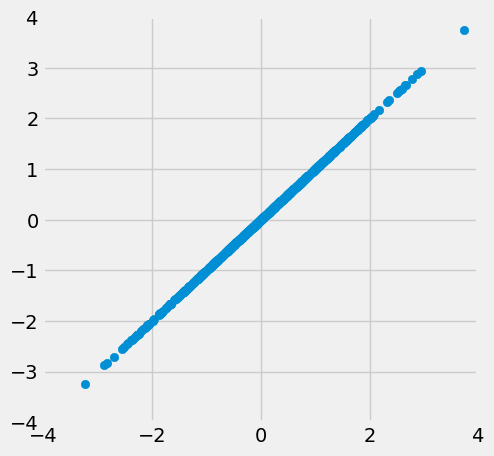

In [16]:
r_scatter(1)

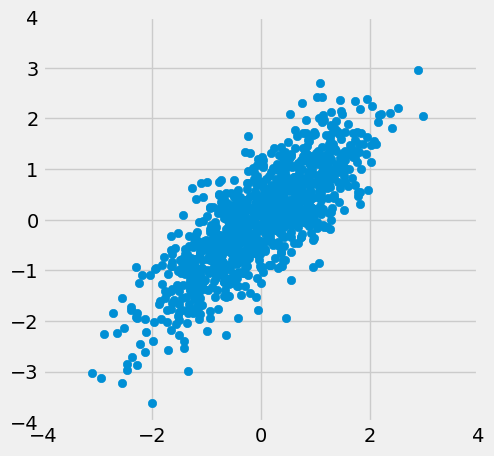

In [17]:
r_scatter(0.8)

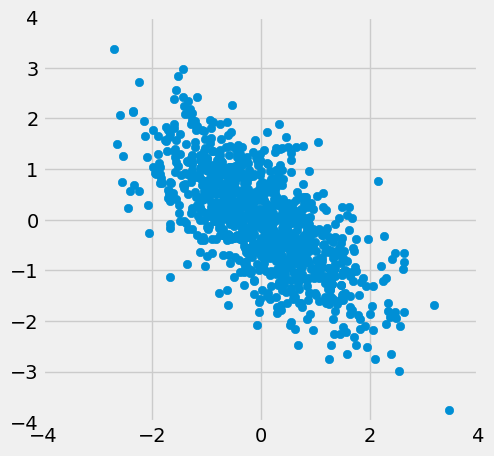

In [18]:
r_scatter(-0.7)

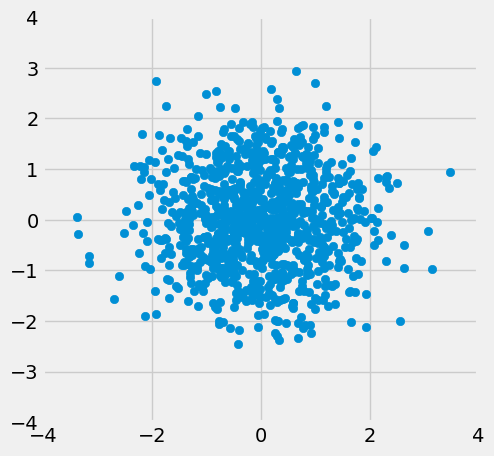

In [19]:
r_scatter(0)

In [23]:
hybrid = Table.read_table('data/hybrid.csv')
hybrid.sample()

vehicle,year,msrp,acceleration,mpg,class
Touareg,2013,62575,16.13,21,SUV
Jetta,2013,24995,12.66,45,Compact
Insight,2003,19137,9.52,53,Two Seater
Crown,2008,62290.4,8.7,37.16,Midsize
Civic,2003,14071.9,8.62,41,Compact
GMC Yukon,2007,57094.8,12.28,21.78,SUV
Lexus RX400h,2005,58521.1,12.76,28.23,SUV
ML450 4natic,2010,55164.3,12.99,22,SUV
Insight,2013,18600,11.76,42,Compact
ActiveHybrid 7,2010,104300,20.41,22.11,Large


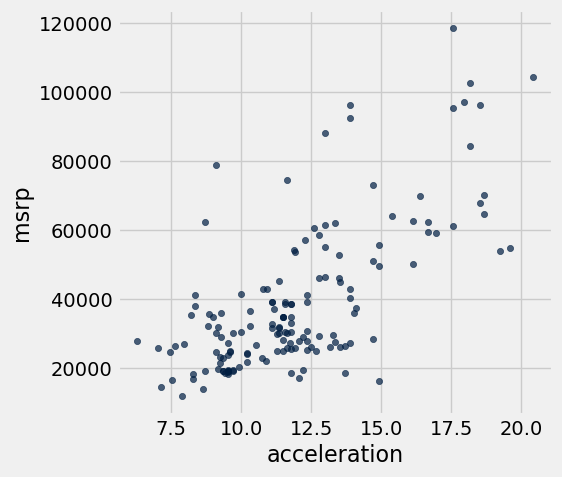

In [21]:
# Crushed ICE: make some scatter plots and see if two variables correlate with each other
hybrid.scatter('acceleration', 'msrp')

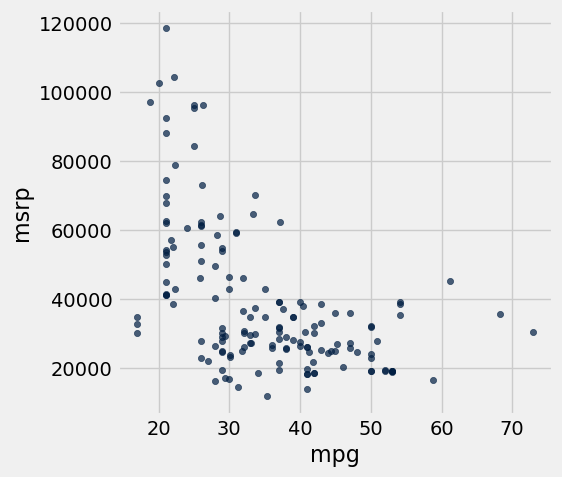

In [22]:
hybrid.scatter('mpg', 'msrp')

In [ ]:
# ^ not linear!

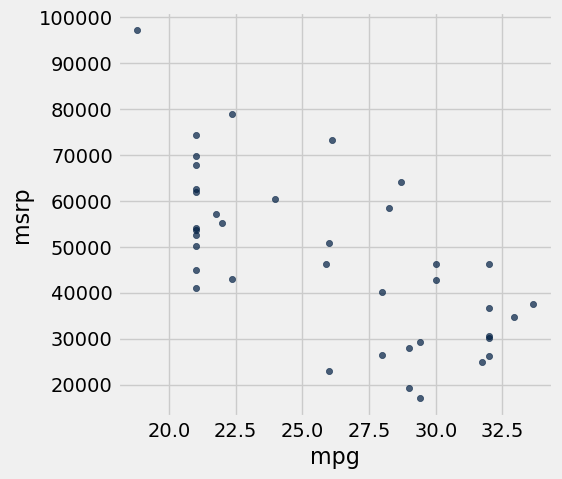

In [24]:
suv = hybrid.where('class', 'SUV')
suv.scatter('mpg', 'msrp')

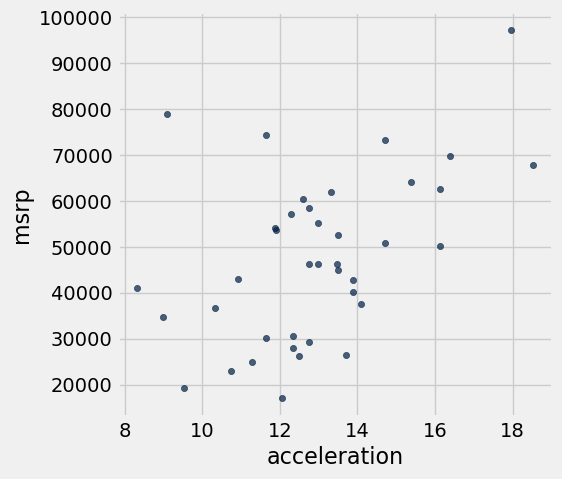

In [25]:
suv.scatter('acceleration', 'msrp')

In [26]:
def standard_units(nums):
    return (nums - np.mean(nums)) / np.std(nums)

In [27]:
suv.column('mpg')

array([ 31.99,  28.23,  29.4 ,  29.  ,  32.93,  22.35,  25.87,  31.75,
        21.78,  26.  ,  22.35,  31.99,  23.99,  18.82,  28.  ,  21.  ,
        21.  ,  28.7 ,  33.64,  29.4 ,  26.11,  29.  ,  32.  ,  30.  ,
        22.  ,  32.  ,  32.  ,  21.  ,  21.  ,  21.  ,  30.  ,  28.  ,
        26.  ,  21.  ,  21.  ,  21.  ,  21.  ,  21.  ,  21.  ])

In [28]:
standard_units(suv.column('mpg'))

array([ 1.31783623,  0.48954981,  0.74728787,  0.6591723 ,  1.52490784,
       -0.80574917, -0.03033209,  1.26496689, -0.93131387, -0.00169453,
       -0.80574917,  1.31783623, -0.4444753 , -1.58336914,  0.43888335,
       -1.10313924, -1.10313924,  0.59308561,  1.68131299,  0.74728787,
        0.02253725,  0.6591723 ,  1.32003912,  0.87946124, -0.8828503 ,
        1.32003912,  1.32003912, -1.10313924, -1.10313924, -1.10313924,
        0.87946124,  0.43888335, -0.00169453, -1.10313924, -1.10313924,
       -1.10313924, -1.10313924, -1.10313924, -1.10313924])

In [30]:
suv.select('mpg', 'msrp')

mpg,msrp
31.99,36676.1
28.23,58521.1
29.4,29186.2
29,19322.6
32.93,34772.4
22.35,42924.3
25.87,46229.5
31.75,24823.8
21.78,57094.8
26,22938.3


In [33]:
suv2 = suv.select('mpg', 'msrp', 'acceleration').with_columns(
    'mpg (standard units)', standard_units(suv.column('mpg')),
    'msrp (standard units)', standard_units(suv.column('msrp')),
    'acceleration (standard units)', standard_units(suv.column('acceleration'))
)
suv2

mpg,msrp,acceleration,mpg (standard units),msrp (standard units),acceleration (standard units)
31.99,36676.1,10.32,1.31784,-0.60884,-1.16157
28.23,58521.1,12.76,0.48955,0.605991,-0.0718039
29.4,29186.2,12.76,0.747288,-1.02536,-0.0718039
29,19322.6,9.52,0.659172,-1.57389,-1.51888
32.93,34772.4,8.98,1.52491,-0.714707,-1.76005
22.35,42924.3,10.91,-0.805749,-0.261367,-0.898064
25.87,46229.5,12.76,-0.0303321,-0.0775641,-0.0718039
31.75,24823.8,11.28,1.26497,-1.26796,-0.732812
21.78,57094.8,12.28,-0.931314,0.526671,-0.286185
26,22938.3,10.75,-0.00169453,-1.37281,-0.969524


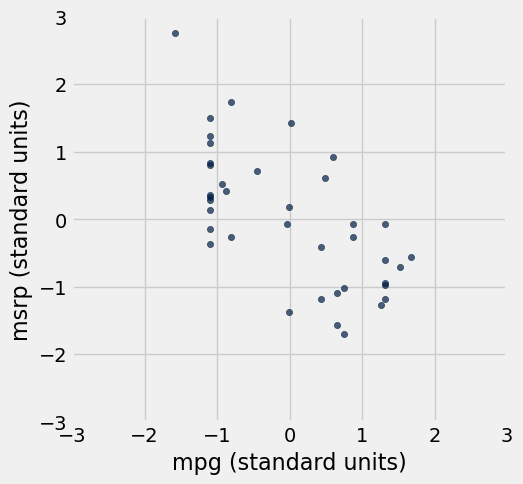

In [35]:
suv2.scatter(3, 4)
plt.xlim(-3, 3)
plt.ylim(-3, 3);

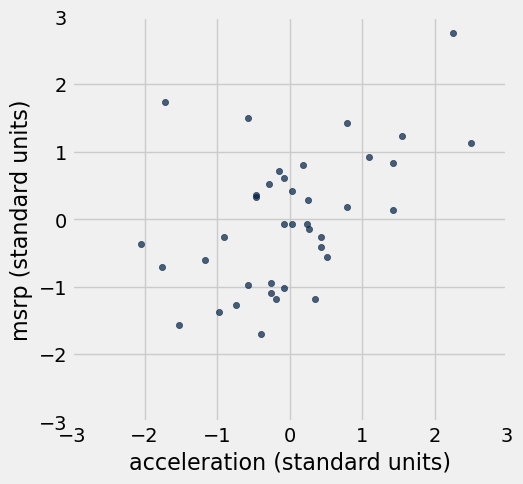

In [36]:
suv2.scatter(5, 4)
plt.xlim(-3, 3)
plt.ylim(-3, 3);

# Calculating r

In [37]:
x = np.arange(1, 7, 1)
y = make_array(2, 3, 1, 5, 2, 7)
t = Table().with_columns(
    'x', x,
    'y', y
)
t

x,y
1,2
2,3
3,1
4,5
5,2
6,7


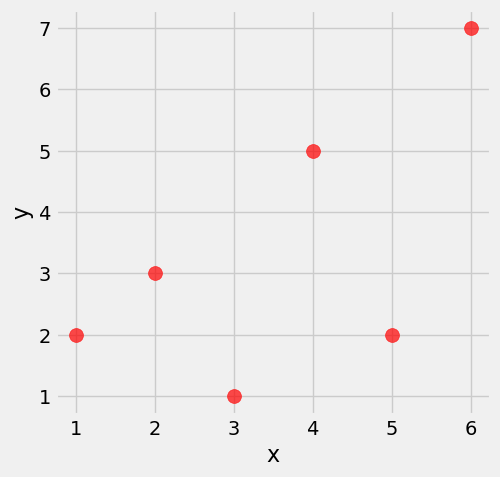

In [41]:
t.scatter(0, 1, s=100, color='red')

In [44]:
t_su = t.with_columns(
    'x (standard units)', standard_units(x),
    'y (standard units)', standard_units(y)
)
t_su

x,y,x (standard units),y (standard units)
1,2,-1.46385,-0.648886
2,3,-0.87831,-0.162221
3,1,-0.29277,-1.13555
4,5,0.29277,0.811107
5,2,0.87831,-0.648886
6,7,1.46385,1.78444


In [46]:
t_product = t_su.with_column('product of standard units', t_su.column(2) * t_su.column(3))
t_product

x,y,x (standard units),y (standard units),product of standard units
1,2,-1.46385,-0.648886,0.949871
2,3,-0.87831,-0.162221,0.142481
3,1,-0.29277,-1.13555,0.332455
4,5,0.29277,0.811107,0.237468
5,2,0.87831,-0.648886,-0.569923
6,7,1.46385,1.78444,2.61215


In [47]:
r = np.mean(t_product.column(4))
r

0.61741639718977093

In [48]:
def correlation(t, x, y):
    return np.mean(standard_units(t.column(x)) * standard_units(t.column(y)))

In [49]:
correlation(t, 'x', 'y')

0.61741639718977093

In [50]:
correlation(t, 'y', 'x')

0.61741639718977093

In [51]:
correlation(suv, 'mpg', 'msrp')

-0.6667143635709919

In [52]:
correlation(suv, 'acceleration', 'msrp')

0.48699799279959155

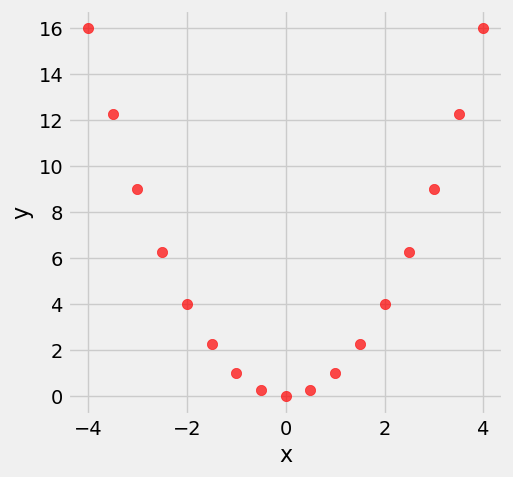

In [54]:
new_x = np.arange(-4, 4.1, 0.5)
nonlinear = Table().with_columns(
    'x', new_x,
    'y', new_x**2
)
nonlinear.scatter('x', 'y', s=55, color='r')

In [55]:
correlation(nonlinear, 'x', 'y')

0.0

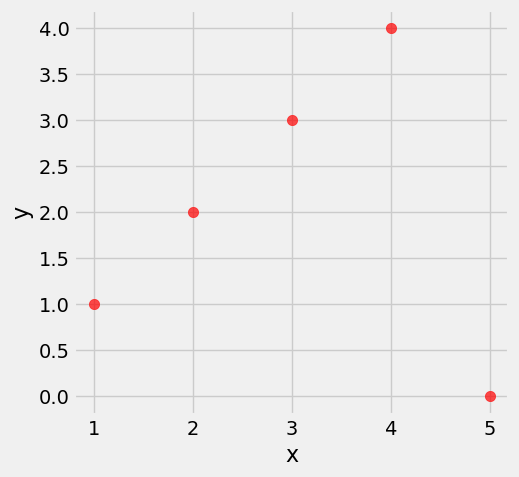

In [56]:
outlier = Table().with_columns(
    'x', make_array(1, 2, 3, 4, 5),
    'y', make_array(1, 2, 3, 4, 0)
)
outlier.scatter('x', 'y', s=55, color='r')

In [57]:
correlation(outlier, 'x', 'y')

0.0

In [58]:
correlation(outlier.where('x', are.below(5)), 'x', 'y')

1.0

# Crushed ICE Examples

In [60]:
sons_heights = Table.read_table('data/sons_heights.csv')
sons_heights

father,mother,son
78.5,67,73.2
75.5,66.5,73.5
75,64,71
75,64,70.5
75,58.5,72
74,68,76.5
74,62,74
73,67,71
73,67,68
73,66.5,71
